# London air quality analysis

* Author: Andrew Sivanesan
* Date: 1st Feb 2026

## Executive summary

TBC

## Background

TBC

In [45]:
import pandas as pd
from pyproj import CRS, Transformer
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
# Initialise a transformer that converts eastings and northings from the British National Grid coordinate reference system (CRS) to latitudes and longitudes in the WGS 1984 ellipsoid CRS
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326")

In [73]:
# define the name of the file to be read into the Pandas DataFrame
fname = "EmissionsByGridID_2022to2030.csv"
# define the columns to select
cols = ['Year', 'Grid ID 2019', 'LAEI 1km2 ID', 'easting', 'northing', 'Zone',
       'Borough', 'Main Source Category', 'Sector', 'Source', "pm10", "pm2.5"]

# define the filter conditions
cond = (df["Year"] == 2022) & (df["Main Source Category"] == "Transport") & (df["Sector"] == "Road Transport")

# read in the file, apply filtering and select columns
df = pd.read_csv(fname)
road_transport = df[cond][cols]

# create latitude and longitude columns
road_transport["Latitude"] = road_transport.apply(lambda x: transformer.transform(x["easting"], x["northing"])[0], axis=1)
road_transport["Longitude"] = road_transport.apply(lambda x: transformer.transform(x["easting"], x["northing"])[1], axis=1)

# drop the easting and northing columns because they are no longer required
road_transport = road_transport.drop(columns=["easting", "northing"])
road_transport

,Year,Grid ID 2019,LAEI 1km2 ID,Zone,Borough,Main Source Category,Sector,Source,pm10,pm2.5,Latitude,Longitude
407944,2022,1,5910.0,Non-GLA,Non-GLA,Transport,Road Transport,Car - Diesel,0.011482,0.005886,51.719355,-0.401759
407945,2022,2,5911.0,Non-GLA,Non-GLA,Transport,Road Transport,Car - Diesel,0.622466,0.367282,51.719157,-0.387288
407946,2022,3,5912.0,Non-GLA,Non-GLA,Transport,Road Transport,Car - Diesel,0.336562,0.193798,51.718957,-0.372818
407947,2022,4,5915.0,Non-GLA,Non-GLA,Transport,Road Transport,Car - Diesel,0.014405,0.007576,51.718348,-0.329411
407948,2022,5,5916.0,Non-GLA,Non-GLA,Transport,Road Transport,Car - Diesel,0.012226,0.006672,51.718142,-0.314942
...,...,...,...,...,...,...,...,...,...,...,...,...
459839,2022,3456,10059.0,Inner London,Southwark,Transport,Road Transport,TfL Bus,0.044190,0.019885,51.499152,-0.106915
459840,2022,3457,10059.0,Central London,Southwark,Transport,Road Transport,TfL Bus,0.296814,0.133059,51.499152,-0.106915
459841,2022,3458,9714.0,Central London,Camden,Transport,Road Transport,TfL Bus,0.281586,0.126538,51.517357,-0.120574
459842,2022,3459,9716.0,Central London,Islington,Transport,Road Transport,TfL Bus,0.017152,0.007711,51.516892,-0.091766


## Exploratory data analysis

* There are **51,900 rows** of data.
* All columns are fully populated i.e. there are **no missing values.**
* pm2.5 and pm10 columns are **very right-skewed**
  
Plot points on a map (will need to install leaflet)

In [75]:
road_transport.describe()

,Year,Grid ID 2019,LAEI 1km2 ID,pm10,pm2.5,Latitude,Longitude
count,51900.0,51900.000000,51900.000000,51900.000000,51900.000000,51900.000000,51900.000000
mean,2022.0,1730.500000,10156.014451,0.049587,0.024491,51.494210,-0.132496
std,0.0,998.825547,2138.729447,0.113132,0.055600,0.111793,0.209424
min,2022.0,1.000000,5910.000000,0.000000,0.000000,51.255332,-0.542382
25%,2022.0,865.750000,8487.750000,0.000764,0.000395,51.409914,-0.297540
50%,2022.0,1730.500000,10058.000000,0.004735,0.002436,51.499384,-0.131851
75%,2022.0,2595.250000,11776.250000,0.034709,0.016885,51.583361,0.031965
max,2022.0,3460.000000,14708.000000,1.539718,0.720619,51.719355,0.328140


In [30]:
road_transport.isnull().sum()

Year                    0
Grid ID 2019            0
LAEI 1km2 ID            0
easting                 0
northing                0
Zone                    0
Borough                 0
Main Source Category    0
Sector                  0
Source                  0
pm10                    0
pm2.5                   0
dtype: int64

In [31]:
road_transport.dtypes

Year                      int64
Grid ID 2019              int64
LAEI 1km2 ID            float64
easting                 float64
northing                float64
Zone                     object
Borough                  object
Main Source Category     object
Sector                   object
Source                   object
pm10                    float64
pm2.5                   float64
dtype: object

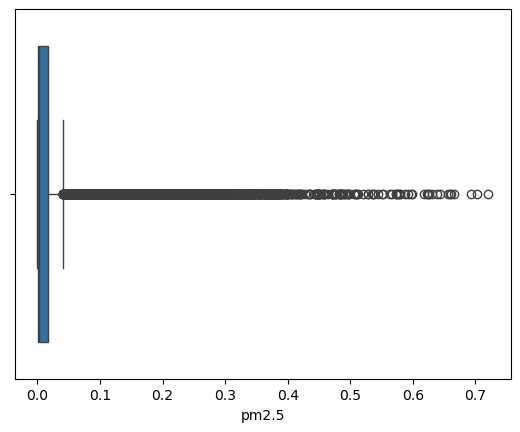

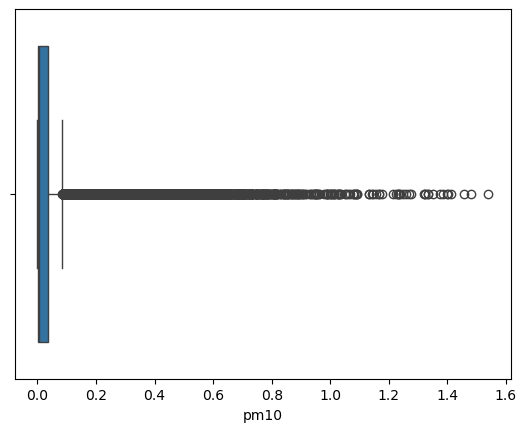

In [74]:
for col in ["pm2.5", "pm10"]:
    sns.boxplot(x=road_transport[col])
    plt.show()

In [76]:
road_transport["Source"].value_counts()

Source
Car - Diesel           3460
Car - Electric         3460
Car - Petrol           3460
HGV - Articulated      3460
HGV - Rigid            3460
LGV - Diesel           3460
LGV - Electric         3460
LGV - Petrol           3460
Motorcycle             3460
Non-TfL Bus / Coach    3460
PHV - Diesel           3460
PHV - Electric         3460
PHV - Petrol           3460
Taxi                   3460
TfL Bus                3460
Name: count, dtype: int64

In [37]:
road_transport["Zone"].value_counts()

In [ ]:
for col in df.columns:
    df[col].isna()